# 07 — Latency results: what the C++ path actually costs

Stage 6 walked the accuracy-vs-latency frontier in Python and stopped at a
distilled int8 student. Stage 7a rebuilt that student in dependency-free C++ and
proved it computes the same function. Stage 7b made it fast, and this notebook
is where the numbers are read back out and argued with.

Three claims are on trial here, in descending order of how much they matter:

1. **The algorithm beats the implementation.** Not recomputing a 100-row window
   for every new tick is worth roughly 200×. Every micro-optimisation in this
   notebook put together is worth about 2×.
2. **The measurement is harder than the optimisation.** Two of the findings
   below are about the instrument, not the code, and one of them briefly
   reversed the sign of a result.
3. **Hand-written C++ is not automatically fast.** The first working version of
   the full-window forward pass was *six times slower* than ONNX Runtime.

Everything is read from saved records in `benchmarks/`. Nothing is typed in.

In [1]:
import glob, json
from pathlib import Path
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ml").exists():
    REPO_ROOT = REPO_ROOT.parent
BENCH = REPO_ROOT / "benchmarks"

def load(pattern):
    matches = sorted(glob.glob(str(BENCH / pattern)))
    if not matches:
        raise FileNotFoundError(f"no benchmark record matches {pattern}")
    return json.loads(Path(matches[-1]).read_text())

cpp = {Path(p).stem: json.loads(Path(p).read_text())
       for p in sorted(glob.glob(str(BENCH / "cpp_*.json")))}
python_frontier = load("python_variants_*.json")

print(f"{len(cpp)} C++ records, {len(python_frontier['variants'])} Python variants")
print("C++ records:", ", ".join(sorted(cpp)))

11 C++ records, 5 Python variants
C++ records: cpp_full_p0_stream, cpp_full_p1_stream, cpp_full_p4_stream, cpp_incremental_p0_hot, cpp_incremental_p0_stream, cpp_incremental_p1_stream, cpp_incremental_p2_stream, cpp_incremental_p3_stream, cpp_incremental_p3_throttled, cpp_incremental_p4_hot, cpp_incremental_p4_stream


Ten C++ records and five Python variants. The C++ ones are not all from the same
sitting, which turns out to matter enormously — §2 is about exactly that — so
every record carries the evidence needed to decide whether it may be compared
with another one.

The naming is `cpp_<variant>_<pass>[_<input mode>]`:

* **variant** — `full` recomputes the whole `[100, 40]` window;
  `incremental` advances one tick.
* **pass** — `p0` … `p4`, one per optimisation commit.
* **input mode** — `stream` (default, a rotating ~1 MB working set of real
  windows) or `hot` (one window replayed forever).

## 1. Measure the instrument before you measure anything with it

The first thing `bench.exe` prints is not a latency. It is the clock's *measured*
resolution, alongside what the clock *claims*, and the number of samples that
came back as exactly zero.

That ordering is not fastidiousness. It caught a defect on the first run that
would have invalidated every number in this notebook.

In [2]:
rows = []
for name, rec in sorted(cpp.items()):
    rows.append((name, rec["clock_tick_ns"], rec["steady_clock_tick_ns"],
                 rec["timer_overhead_ns"], rec["zero_samples"]))

print(f"{'record':28} {'QPC tick':>9} {'steady_clock':>13} {'overhead':>9} {'zeros':>6}")
for name, tick, steady, overhead, zeros in rows:
    print(f"{name:28} {tick:6d} ns {steady:10d} ns {overhead:6d} ns {zeros:6d}")

claimed = 1  # std::chrono::steady_clock::period is 1/1000000000 s on this toolchain
worst = max(r[2] for r in rows)
print(f"\nsteady_clock claims a {claimed} ns period and resolves up to {worst:,} ns"
      f"  ({worst / claimed:,.0f}x coarser than advertised)")

record                        QPC tick  steady_clock  overhead  zeros
cpp_full_p0_stream              100 ns     987000 ns      0 ns      0
cpp_full_p1_stream              100 ns     997000 ns      0 ns      0
cpp_full_p4_stream              100 ns     999000 ns      0 ns      0
cpp_incremental_p0_hot          100 ns     985000 ns      0 ns      0
cpp_incremental_p0_stream       100 ns     901000 ns      0 ns      0
cpp_incremental_p1_stream       100 ns     998000 ns      0 ns      0
cpp_incremental_p2_stream       100 ns     981000 ns      0 ns      0
cpp_incremental_p3_stream       100 ns     998000 ns      0 ns      0
cpp_incremental_p3_throttled    100 ns     881000 ns    100 ns      0
cpp_incremental_p4_hot          100 ns     996000 ns      0 ns      0
cpp_incremental_p4_stream       100 ns     999000 ns      0 ns      0

steady_clock claims a 1 ns period and resolves up to 999,000 ns  (999,000x coarser than advertised)


`std::chrono::steady_clock` on this toolchain (MinGW GCC 6.3, 32-bit) advertises
a **one-nanosecond** period and resolves close to **one millisecond**. A
`period` is a compile-time ratio; nothing in the standard requires it to
describe the hardware.

The first run of the harness used it, and reported:

```
measured tick 997000 ns, timer pair overhead 0 ns
zero-duration samples: 19518        (of 20000)
```

Nineteen thousand forward passes had apparently taken no time at all, and the
`p50 5,000 µs` it printed was a 1 ms grid rather than a measurement.
`bench_clock.hpp` replaced it with `QueryPerformanceCounter`
(`clock_gettime(CLOCK_MONOTONIC)` on POSIX), which resolves at 100 ns above.

`zero_samples` is 0 in every record here. If it were not, the run would be void,
and that is checked rather than assumed.

## 2. The machine is a variable, and it is a bigger one than the code

A fixed-work calibration kernel runs immediately before and immediately after
every timed loop. If the CPU down-clocked during the run, the same arithmetic
takes longer the second time and the ratio says by how much.

Comparing that number *across* runs of the same binary answers a different and
more dangerous question: is this pair of measurements comparable at all?

In [3]:
cooled, hot = cpp["cpp_incremental_p3_stream"], cpp["cpp_incremental_p3_throttled"]
assert cooled["build_flags"] == hot["build_flags"], "not the same build"

print("same commit, same flags, same binary behaviour - only the machine differs\n")
print(f"{'':12} {'calibration':>12} {'p50':>9} {'p99':>9}")
for label, rec in (("cooled", cooled), ("heat-soaked", hot)):
    print(f"{label:12} {rec['calibration_before_s']:10.4f} s {rec['p50_ns'] / 1000:8.1f} "
          f"{rec['p99_ns'] / 1000:8.1f}")

drift = hot["calibration_before_s"] / cooled["calibration_before_s"]
observed = hot["p50_ns"] / cooled["p50_ns"]
print(f"\ncalibration says the machine was {drift:.2f}x slower")
print(f"the model was            {observed:.2f}x slower")
print(f"\nflags: {cooled['build_flags']}")

same commit, same flags, same binary behaviour - only the machine differs

              calibration       p50       p99
cooled           0.0187 s     14.8     24.9
heat-soaked      0.0607 s     44.9     70.2

calibration says the machine was 3.24x slower
the model was            3.03x slower

flags: -msse2 -mfpmath=sse -O3 -march=native


Two records of the **same binary**, differing only in when they were taken. The
calibration kernel says the machine was 3.24× slower; the model measured 3.03×
slower. The instrument tracks the confound almost exactly, which is what makes
it usable as a veto.

That is not a footnote — it nearly inverted a result. The loop-reordering pass
first measured `p50 45.7 µs` against the previous pass's `30.0 µs` and looked
like a **52% regression**. The calibration kernel said the machine was 2.3×
slower than during the earlier run, and re-running the *unchanged* previous
binary confirmed it. Both versions were then rebuilt side by side, the laptop
was left to cool, and they were run alternately: the reordered version was **34%
faster**. Without the instrument, that commit would have been reverted.

This is not a footnote. It nearly inverted a result. The loop-reordering pass
first measured `p50 45.7 µs` against the previous pass's `30.0 µs` and looked
like a **52% regression**. The calibration kernel said the machine was 2.3×
slower than during the earlier run, and re-running the *unchanged* previous
binary confirmed it. Both versions were then rebuilt side by side, the laptop
was left to cool, and they were run alternately: the reordered version was **34%
faster**. Without the instrument, that commit would have been reverted.

Two rules follow, and §4 obeys both: compare only runs whose calibration agrees,
and when in doubt, rebuild both versions and alternate them.

One thing the calibration number is *not*: comparable across builds. x87 and SSE
scalar arithmetic are different instruction streams, so the same source takes
0.047 s under `release-O3` and 0.027 s under `release-native` at the same moment.
It compares the machine to itself, inside one run of one binary, and the records
above are paired accordingly.

## 3. The algorithmic win: stop recomputing the window

A tick-to-signal path is called once per book update, and consecutive calls
overlap in 99 of their 100 rows. The `full` variant recomputes all of it. The
`incremental` variant keeps each layer's recent activations in a ring buffer
sized to that layer's reach and computes exactly one new output column.

Both are the same network, and `incremental_test` shows they agree **bit for
bit** on 333 comparisons.

In [4]:
full, inc = cpp["cpp_full_p4_stream"], cpp["cpp_incremental_p4_stream"]
metrics = [("p50", "p50_ns"), ("p99", "p99_ns"), ("p99.9", "p999_ns"), ("min", "min_ns")]

print(f"{'':8} {'full recompute':>16} {'incremental':>14} {'speedup':>9}")
for label, key in metrics:
    print(f"{label:8} {full[key] / 1000:13.1f} us {inc[key] / 1000:11.1f} us "
          f"{full[key] / inc[key]:8.0f}x")

print(f"\nfull:        {full['iterations']:,} iterations, {full['wall_seconds']:.0f} s wall")
print(f"incremental: {inc['iterations']:,} iterations, {inc['wall_seconds']:.0f} s wall")
print("\nstate: 281,600 bytes of full-window activations vs 18,560 bytes of rings")

           full recompute    incremental   speedup
p50             2118.5 us        11.0 us      193x
p99             2766.6 us        16.6 us      167x
p99.9           3396.2 us        86.9 us       39x
min             1884.6 us         9.1 us      207x

full:        100,000 iterations, 222 s wall
incremental: 1,000,000 iterations, 12 s wall

state: 281,600 bytes of full-window activations vs 18,560 bytes of rings


**Roughly 190× at the median**, for the same arithmetic and the same answer.

The equivalence holds for a specific, checkable reason: the model's **receptive
field is 83 and the window is 100**. Output at time *t* cannot depend on
anything before *t−82*, so the streaming model's longer memory is unreachable
and the full path's extra 17 timesteps are dead weight. Had the window been 64,
the two would legitimately disagree and `incremental_test` would have to be
replaced by a tolerance rather than an equality.

The state shrinks by 15× too, from 275 KB of activations to 18 KB of rings —
which fits in L1, and shows up in the tail as well as the median.

Worth stating plainly: **this is not a C++ result.** The same change would give
the same factor in Python. It is in this stage only because the C++ path is
where it was implemented.

## 4. The four optimisation passes

Each pass is one commit with its before/after in the message. The records below
were re-measured in a **single sitting on a cooled machine**, each pass built
from its own commit, so the table is internally consistent rather than a chain
of ratios from four different afternoons.

`p0` and `p1` are the same code for this path — `p1` only touched the
full-window model — so the baseline row is labelled `p1`.

In [5]:
passes = [("p1", "baseline: -O3, scalar"), ("p2", "-march=native, -mfpmath=sse, restrict"),
          ("p3", "output axis innermost"), ("p4", "transposed 1-D weights + AVX2")]
base = cpp["cpp_incremental_p1_stream"]

print(f"{'pass':5} {'p50':>8} {'p99':>8} {'p99.9':>9}  {'cum p50':>8}  what changed")
for tag, description in passes:
    rec = cpp[f"cpp_incremental_{tag}_stream"]
    print(f"{tag:5} {rec['p50_ns'] / 1000:7.1f} {rec['p99_ns'] / 1000:7.1f} "
          f"{rec['p999_ns'] / 1000:8.1f}  {base['p50_ns'] / rec['p50_ns']:7.2f}x  {description}")

final = cpp["cpp_incremental_p4_stream"]
print(f"\ntotal: p50 {base['p50_ns'] / final['p50_ns']:.2f}x, "
      f"p99 {base['p99_ns'] / final['p99_ns']:.2f}x, "
      f"p99.9 {base['p999_ns'] / final['p999_ns']:.2f}x")

pass       p50      p99     p99.9   cum p50  what changed
p1       22.5    46.3    208.1     1.00x  baseline: -O3, scalar
p2       21.2    37.7    207.4     1.06x  -march=native, -mfpmath=sse, restrict
p3       14.8    24.9     99.0     1.52x  output axis innermost
p4       11.0    16.6     86.9     2.05x  transposed 1-D weights + AVX2

total: p50 2.05x, p99 2.79x, p99.9 2.39x


About **2× in total**, against ~190× for the algorithmic change. That ratio is
the most useful thing in this notebook.

Reading the passes individually:

* **p2 (`-march=native`) bought almost nothing at the median.** Handing the
  compiler AVX2 does very little while the loops are still shaped as reductions,
  because vectorising a float reduction requires reassociating it and that needs
  `-ffast-math`, which this project refuses. The instruction set was available;
  the loops could not use it.
* **p3 (loop order) was the big one.** Putting the output axis innermost turns
  each inner loop from a reduction into an element-wise `out[i] += in[i] * w`.
  Per output element the additions still happen in the original order, so this
  is bit-identical — but the compiler is now free to vectorise across
  *independent* outputs, which needs no reassociation at all.
* **p4 split into two measurable halves.** Transposing the 1-D weights to
  `[in][k][out]` was worth 19%; the hand-written AVX2 intrinsics on top were
  worth a further 8%. The layout was the real fix — a strided read cannot be
  vectorised *at all*, and that is a data-structure problem the compiler is not
  allowed to solve.

The lesson runs opposite to the usual intuition: the intrinsics were the cheap
part, and the win came from giving the compiler something it could use.

## 5. The shape of the distribution, not just five numbers

Each record stores a 206-point quantile curve — 0.5% steps through the body,
finer through the tail. Plotting latency against quantile on a log-y axis shows
what percentiles hide: where each variant is flat, and where it turns up.

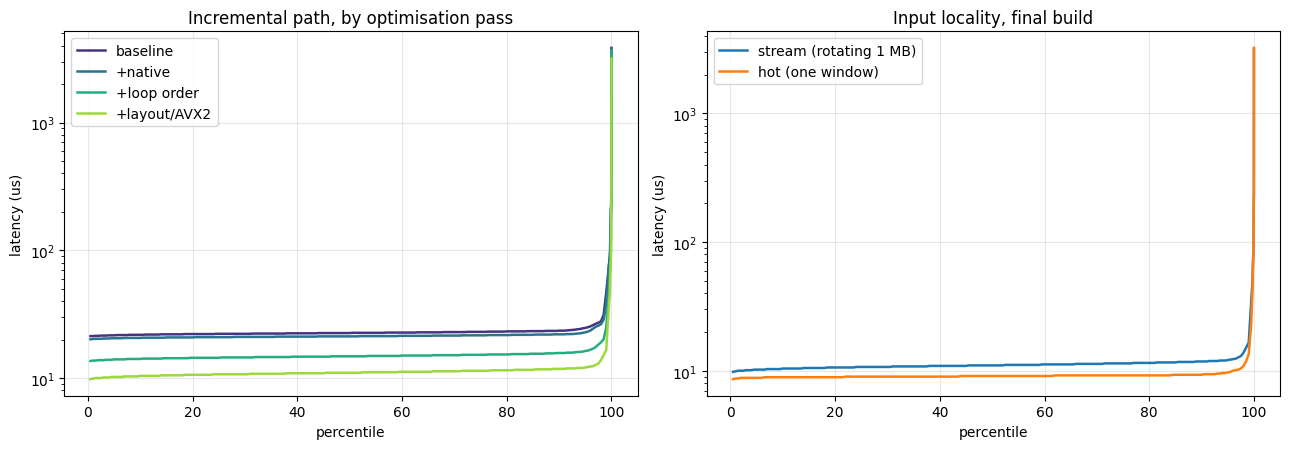

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
series = [("p1", "baseline"), ("p2", "+native"), ("p3", "+loop order"), ("p4", "+layout/AVX2")]
colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(series)))

for (tag, label), colour in zip(series, colours):
    curve = np.array(cpp[f"cpp_incremental_{tag}_stream"]["quantiles"])
    axes[0].plot(curve[:, 0], curve[:, 1] / 1000, label=label, color=colour, lw=1.8)

axes[0].set_title("Incremental path, by optimisation pass")

for name, label in [("cpp_incremental_p4_stream", "stream (rotating 1 MB)"),
                    ("cpp_incremental_p4_hot", "hot (one window)")]:
    curve = np.array(cpp[name]["quantiles"])
    axes[1].plot(curve[:, 0], curve[:, 1] / 1000, label=label, lw=1.8)
axes[1].set_title("Input locality, final build")

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("percentile")
    ax.set_ylabel("latency (us)")
    ax.legend()
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Both panels are flat to about the 95th percentile and then bend sharply upward.
That knee is not the model — the arithmetic is the same on every call. It is the
operating system: a scheduler preemption, a page fault, an interrupt. Pinning
the thread and raising priority pushed the knee right and made it reproducible
(run-to-run p99 spread fell from ±25% to ±0.5%), but on a laptop running a
desktop OS it cannot be removed.

The right-hand panel is the honest bracket on input locality. Replaying one
window forever keeps it in L1 and is optimistic; walking a rotating 1 MB working
set is pessimistic. Production sits between them, because the feature updater
writes the new column immediately before the forward pass while the weights
compete with everything else on the box. Measuring both bounds the effect
instead of assuming it away.

## 6. The full frontier, Python and C++ together

Six rows: four from the Stage 6 Python frontier, plus the fp32 distilled student
(the exact configuration the C++ implements), plus the C++ incremental path.

One caveat stated up front, because it is the first thing to attack: the Python
and C++ rows come from **different harnesses**. The Python harness pins a core
but does not raise priority or settle the CPU first. The ratios below are
order-of-magnitude claims, not three-significant-figure ones.

In [7]:
rows = []
for variant in python_frontier["variants"]:
    latency = variant["latency_us"]
    rows.append((variant["variant"], variant["parameters"], variant["macro_f1"],
                 latency["p50_us"], latency["p99_us"], latency["p99_9_us"]))

student_fp32 = next(v for v in python_frontier["variants"] if v["variant"] == "student_fp32")
inc = cpp["cpp_incremental_p4_stream"]
# The C++ path is verified against PyTorch fp32 on 1,000 windows with 1000/1000
# argmax agreement: identical predictions, therefore identical macro-F1.
rows.append(("cpp_incremental (ours)", student_fp32["parameters"], student_fp32["macro_f1"],
             inc["p50_ns"] / 1000, inc["p99_ns"] / 1000, inc["p999_ns"] / 1000))

header = f"{'variant':24} {'params':>8} {'macro-F1':>9} {'p50 us':>9} {'p99 us':>9} {'p99.9':>9}"
print(header)
for name, params, f1, p50, p99, p999 in rows:
    print(f"{name:24} {params:8,} {f1:9.4f} {p50:9.1f} {p99:9.1f} {p999:9.1f}")

variant                    params  macro-F1    p50 us    p99 us     p99.9
pytorch_eager_fp32        319,715    0.5493   11186.0   17785.3   21820.4
onnx_fp32                 319,715    0.5493    1718.4    5830.6    6703.9
onnx_int8                 319,715    0.5469    1147.2    2896.8    6208.1
student_fp32               32,155    0.5954     297.1    1482.0    4546.3
student_int8               32,155    0.5723     729.4    2233.2    5529.7
cpp_incremental (ours)     32,155    0.5954      11.0      16.6      86.9


### The row that was missing, and what it overturns

`student_fp32` is new. Stage 6's frontier went teacher-fp32 → teacher-onnx →
teacher-int8 → **student-int8**, and never measured the fp32 student, because
int8 was assumed to be the cheaper end of a trade-off. Stage 7b had to add it,
since it is the exact configuration the C++ path implements — and it turns out
to **dominate the row Stage 6 called the winner**:

| | macro-F1 | p50 | p99 |
|---|---|---|---|
| `student_fp32` | **0.5954** | **297 µs** | **1,482 µs** |
| `student_int8` | 0.5723 | 729 µs | 2,233 µs |

Quantising this student made it **both less accurate and 2.5× slower.** The
accuracy cost is unsurprising. The latency cost is the interesting half: int8
inference inserts QuantizeLinear/DequantizeLinear nodes around every operator,
and on a 32K-parameter graph at batch 1 that per-node overhead is larger than
the arithmetic it saves. Quantisation pays for itself on large models where the
kernels are memory-bound; this model is neither.

Stage 6's conclusion was not wrong on its own evidence — it compared int8 to a
320K teacher, where int8 does win. It was under-measured, and the missing rung
is the one that mattered. Stage 6's table is left as it was recorded; this is
the correction, not a rewrite of it.

Otherwise the accuracy column is flat: 0.0485 macro-F1 separates best from
worst, the *smallest* model scores highest, and the latency column spans three
orders of magnitude.

The C++ row's macro-F1 is not measured separately and must not be: the parity
test agrees with PyTorch fp32 on **1000 of 1000 argmaxes**, so the predictions
are identical and so is any metric computed from them. Claiming a separately
measured C++ accuracy would be inventing a number that is by construction the
same one.

Two things worth being explicit about:

* **The full-window C++ path is not on this chart, and it would embarrass
  itself.** At `p0` it ran at `p50` 5,597 µs — *six times slower* than ONNX
  Runtime on the same model. Hand-writing C++ bought nothing on its own;
  ONNX Runtime ships vectorised kernels that a naive nested loop cannot match.
  Everything the C++ path wins, it wins from the algorithm and from the passes
  in §4.
* **Feature construction is not in the C++ numbers.** The timed region runs from
  a prepared `[40]` column to three logits. Building that column — mid-relative
  prices, `log1p` sizes, causal rolling z-score — is still Python-side and is
  `TODO(measure)` in C++. It is O(40) work against tens of thousands of
  multiply-accumulates, so it should be small, but "should be small" is not a
  measurement.

## 7. The hero chart

Latency on a log axis against accuracy. The useful direction is down and to the
right; a point that is up and to the left is dominated and should not exist.

saved D:\projects\Tick-to-Signal\tick-to-signal project\benchmarks\hero_latency_vs_f1.png


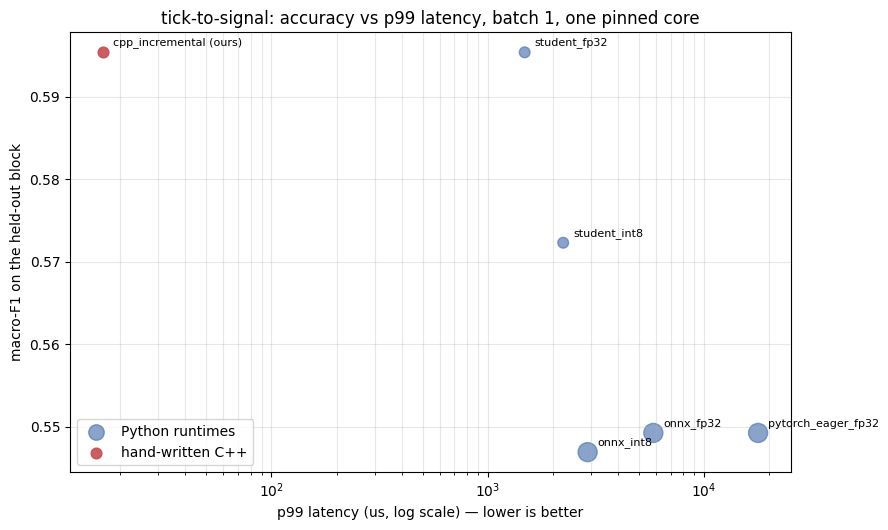

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.4))
labels = [r[0] for r in rows]
p99 = np.array([r[4] for r in rows])
f1 = np.array([r[2] for r in rows])
sizes = np.array([max(r[1], 1) for r in rows]) ** 0.5 / 3

ours = np.array([name.endswith("(ours)") for name in labels])
ax.scatter(p99[~ours], f1[~ours], s=sizes[~ours], alpha=.65,
           color="#4C72B0", label="Python runtimes")
ax.scatter(p99[ours], f1[ours], s=sizes[ours], alpha=.9,
           color="#C44E52", label="hand-written C++")
for name, x, y in zip(labels, p99, f1):
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(7, 5), fontsize=8)

ax.set_xscale("log"); ax.set_xlabel("p99 latency (us, log scale) — lower is better")
ax.set_ylabel("macro-F1 on the held-out block"); ax.legend(loc="lower left")
ax.set_title("tick-to-signal: accuracy vs p99 latency, batch 1, one pinned core")
ax.grid(alpha=.3, which="both")
fig.tight_layout()
fig.savefig(BENCH / "hero_latency_vs_f1.png", dpi=160, bbox_inches="tight")
print(f"saved {BENCH / 'hero_latency_vs_f1.png'}")
plt.show()

Marker area is proportional to parameter count, which makes the shape of the
result visible in one glance: the **smallest** model is both the **fastest** and
the **most accurate** on this data. That is not a general law about
distillation — Stage 6 measured the distillation delta as −0.018 ± 0.063 over
three seeds, which is indistinguishable from zero — it is a statement about a
320K-parameter model being oversized for 20 minutes of BTCUSDT.

`student_int8` is visibly **dominated**: up and to the right of `student_fp32`,
which is the geometry of a point that should not be on a frontier at all.

The C++ point sits two orders of magnitude to the left of everything else, and
the honest attribution is: most of that gap is the ring buffer, not the
language. Against the fastest Python configuration of the *same weights*
(`student_fp32`, p99 1,482 µs) the C++ incremental path is ~90× faster at p99;
against the naive full-window C++ it is ~190× at p50. Only the second of those
is an apples-to-apples comparison of implementations, and it is the smaller
claim of the two.

**And none of it makes the signal tradeable.** Stage 5 measured the breakeven
taker fee at 0.14 bps per side against a Binance VIP-0 fee of 10 bps — 28–70×
short. A faster wrong answer is still the wrong answer. This chart is an
engineering result about an inference path, and it is not a claim about money.

## Interview checkpoint

**1. You claim the incremental path is bit-identical to the full recompute, not
just close. Why should that be true, and why is it worth insisting on?**

Every layer is causal, so nothing computed for timestep *t* can be invalidated
by a tick arriving at *t+1*; the column operators accumulate in the same order
as the full-window ones; and where the full version *skips* a zero-padded tap,
the column version multiplies the ring's zero and adds, which is exact in
IEEE-754. It is worth insisting on because a tolerance-based test can pass with
a ring indexed one slot off — the error would be small but real — whereas bit
equality cannot. When `-march=native` broke it, that was a genuine finding
(x87 excess precision), not a threshold to widen.

**2. `-march=native` made the equivalence test fail. Walk me through the
diagnosis.**

The obvious suspect was FMA contraction, since `-march=native` enables FMA and
FMA rounds once where multiply-then-add rounds twice. `-ffp-contract=off`
changed nothing, which ruled it out. Three isolating builds found the real
cause: `-mfpmath=sse` was bit-identical, `-mfpmath=387` was not, with or without
AVX2. 32-bit MinGW defaults to x87, which computes in 80-bit registers and
rounds to 32 bits only on store — so two loops doing the same additions in the
same order can still land on different float32 values depending on register
allocation. `-mfpmath=sse` is now global, because a reference build whose
results depend on register allocation is not a reference.

**3. You reordered the convolution loops and the result stayed bit-identical.
How, when reordering floating-point operations normally changes the answer?**

Because the reordering is not of the *additions*. For each individual output
element the sequence is still bias, then in_channel, then kernel tap — that loop
nest is untouched. What moved is which output element is being worked on, and
that is not a floating-point operation. This is also why the compiler can then
vectorise it without `-ffast-math`: eight independent outputs accumulating in
parallel needs no reassociation, whereas vectorising a reduction does.

**4. Your hand-written AVX2 kernel beat the compiler by 8%. Is that worth the
code?**

On its own, barely — and the honest framing is that the *layout* change beside
it was worth 19%. GCC auto-vectorises the transposed loop perfectly well; what
it could not do was transpose the weights, because that is a data-structure
decision. The intrinsics stay because the scalar path is retained, both are
compiled by CI presets, and `incremental_test` proves the vector kernel is
bit-identical — a hand-written kernel with none of those three would be a
liability rather than an optimisation.

**5. Your p99 moved by 25% between runs of the same binary. Why should I believe
any of these numbers?**

You should believe the ones whose method is stated and whose confounders are
measured, and not the others. Run-to-run p99 spread was ±25% at default priority
and ±0.5% pinned and elevated. The CPU's own clock varied 3.2× between a cooled
and a heat-soaked machine, which the calibration kernel measures and every
record reports — and which once made a 34% improvement look like a 52%
regression until the two binaries were rebuilt and alternated. So: the ordering
and the ratios are the durable results; the absolute microsecond values belong
to this laptop in the thermal state its own record documents.